<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/filtering/Mukundan_ec_filt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E. coli - Filtering

### By: Mukundan Thanigaivelan

#### July 9, 2026

In this notebook, we filter E. coli genes and samples to roughly obtain a normal distribution of our gene expression for inputting into the Denoising AutoEncoder (DAE).

We work with genes in MG1655, and the data have already been filtered based on sparsity and housekeeping genes, as well as log-transformed and 0-1 scaled.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 505, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 505 (delta 99), reused 49 (delta 16), pack-reused 323 (from 1)
Receiving objects: 100% (505/505), 46.72 MiB | 17.01 MiB/s, done.
Resolving deltas: 100% (252/252), done.
Updating files: 100% (153/153), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/filtering

/content/seqADAGE/Py/muk_transfer_learning/filtering


In [3]:
!pip install -qq seaborn pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.3/186.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

## 2. Loading classes & modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import tensorflow as tf

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
True


## 3. Data filtering

Here we are looking at genes in MG1655. Samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

### Preparation

In [ ]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [ ]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 4272 genes (features) and 16150 samples


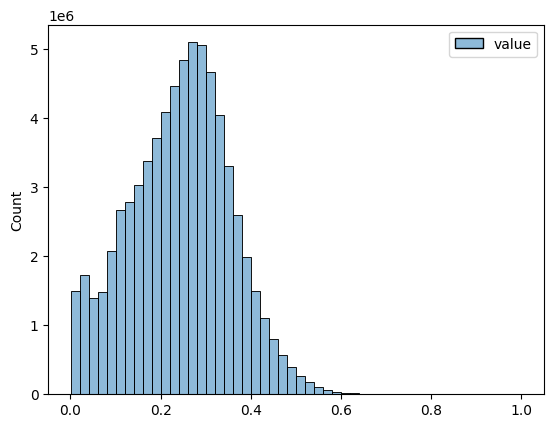

In [ ]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

### Gene-wise Filtering

In [ ]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
11997cc26382b2c286cd502685a104a5_13,16150.0,0.290959,0.049891,0.005090,0.263131,0.284746,0.309190,0.571206
11997cc26382b2c286cd502685a104a5_45,16150.0,0.277920,0.057231,0.002175,0.261675,0.284082,0.305577,0.597320
11997cc26382b2c286cd502685a104a5_102,16150.0,0.213072,0.107602,0.000692,0.119966,0.243526,0.290658,0.742326
11997cc26382b2c286cd502685a104a5_110,16150.0,0.312207,0.066389,0.032919,0.295633,0.324393,0.347428,0.754336
11997cc26382b2c286cd502685a104a5_72,16150.0,0.364656,0.082157,0.022983,0.299426,0.356862,0.427053,0.715735


Text(0.5, 1.0, 'Mean vs. Median expression')

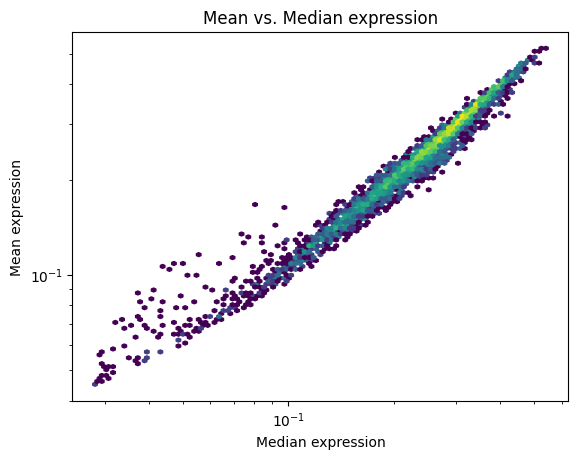

In [ ]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [ ]:
# Empirically determined constants to draw a separation line
c = 0.9
median_cutoff = 0.12

x = np.linspace(median_cutoff, 0.6, 200)
y = c*x

Text(0.5, 1.0, 'Mean vs. Median expression')

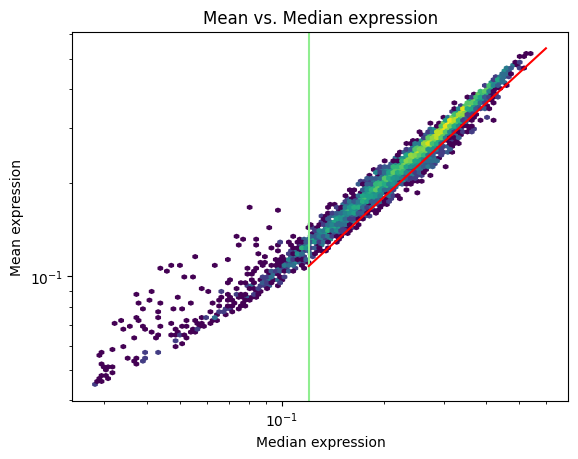

In [ ]:
# Hexagonal binning log-scaled plot of median versus mean - included thresholds
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)

plt.axvline(median_cutoff, color = 'lightgreen')
plt.plot(x, y, color = 'red')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [ ]:
# Set thresholds to remove genes
threshold1 = median_cutoff
threshold2 = c*gene_stats['50%']

# Genes to remove
genes_to_rm = gene_stats[(gene_stats['50%'] < threshold1) | (gene_stats['mean'] < threshold2)]
genes_to_rm.shape

(664, 8)

In [ ]:
# Remove the genes
filtered_genes = all_comp.drop(index = genes_to_rm.index)
filtered_genes.shape

(3608, 16150)

In [ ]:
# Get filtered gene stats
filtered_stats = filtered_genes.T.describe().T

Text(0.5, 1.0, 'Mean vs. Median expression')

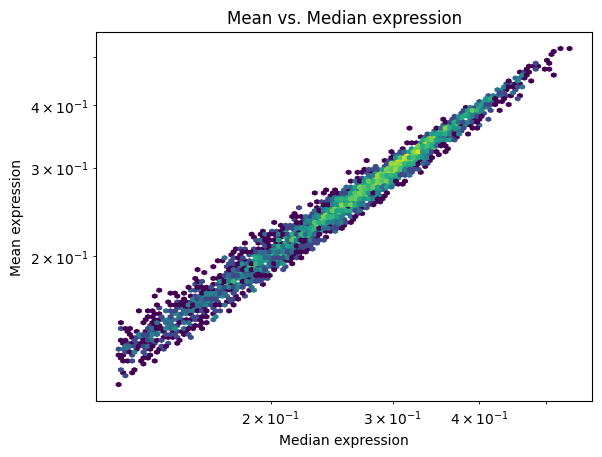

In [ ]:
# Plot of gene expression median versus mean after filtering
plt.hexbin(
  x = filtered_stats['50%'],
  y = filtered_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

<Axes: ylabel='Count'>

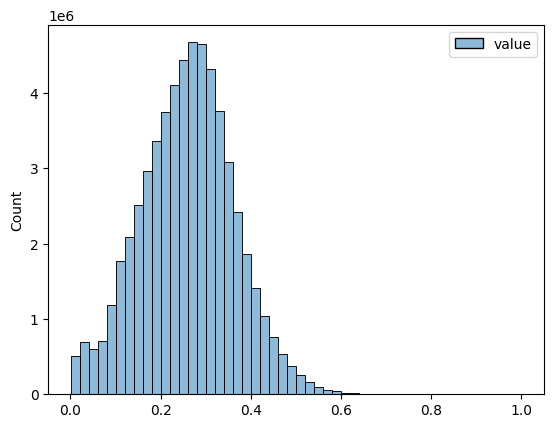

In [ ]:
# Histogram of gene expression - getting normal but needs work
sns.histplot(pd.melt(filtered_genes), bins=50)

### Experiment-wise Filtering

In [ ]:
# Get experiment statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
ERX358242.salmon,3608.0,0.259334,0.080874,0.037627,0.207913,0.258373,0.309569,0.538706
ERX358243.salmon,3608.0,0.260587,0.085040,0.026616,0.205225,0.260042,0.315398,0.536585
ERX358244.salmon,3608.0,0.259824,0.082692,0.025180,0.207999,0.258959,0.313029,0.527667
ERX358245.salmon,3608.0,0.260435,0.085708,0.039842,0.204903,0.261084,0.316369,0.559430
ERX358246.salmon,3608.0,0.258781,0.089028,0.027814,0.201201,0.258916,0.316990,0.549574


Text(0.5, 1.0, 'Mean vs. Median expression')

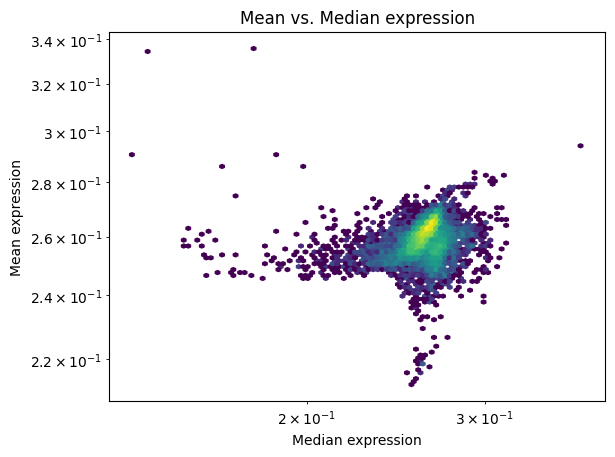

In [ ]:
# Prelimiary plot of mean by median expression - weird shape
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [ ]:
# Empirically derived constants to filter out samples
c1, c2 = 0.98, 1.02

# Cutoff lines to filter samples
x = np.linspace(0.21, 0.31, 200)
y1 = c1 * x
y2 = c2 * x

Text(0.5, 1.0, 'Mean vs. Median expression')

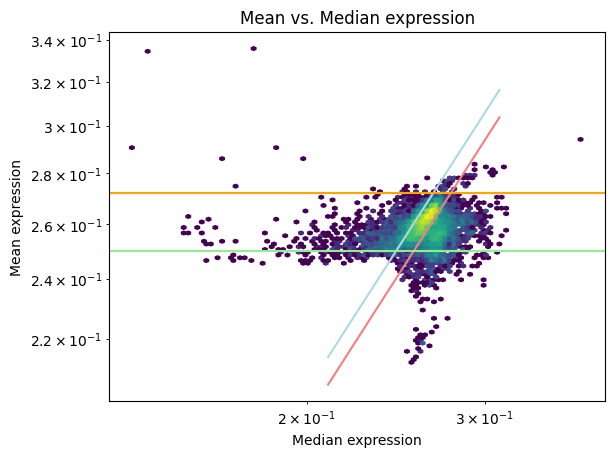

In [ ]:
# Plot with threshold lines for filtering out samples
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)

plt.plot(x, y1, color = 'lightcoral')
plt.plot(x, y2, color = 'lightblue')
plt.axhline(0.25, color = 'lightgreen')
plt.axhline(0.272, color = 'orange')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [ ]:
# Thresholds to filter out samples
threshold1 = c1 * exp_stats['50%']
threshold2 = c2 * exp_stats['50%']
threshold3 = 0.25
threshold4 = 0.272

# Samples to remove
exps_to_rm = exp_stats[
  (exp_stats['mean'] < threshold1) |
  (exp_stats['mean'] > threshold2) |
  (exp_stats['mean'] < threshold3) |
  (exp_stats['mean'] > threshold4)
]
exps_to_rm.shape

(5996, 8)

In [ ]:
# Get final filtered data set
filtered_df = filtered_genes.drop(columns = exps_to_rm.index)
filtered_df.shape

(3608, 10154)

In [ ]:
# Get statistics on final data
final_stats = filtered_df.describe().T

Text(0.5, 1.0, 'Mean vs. Median expression')

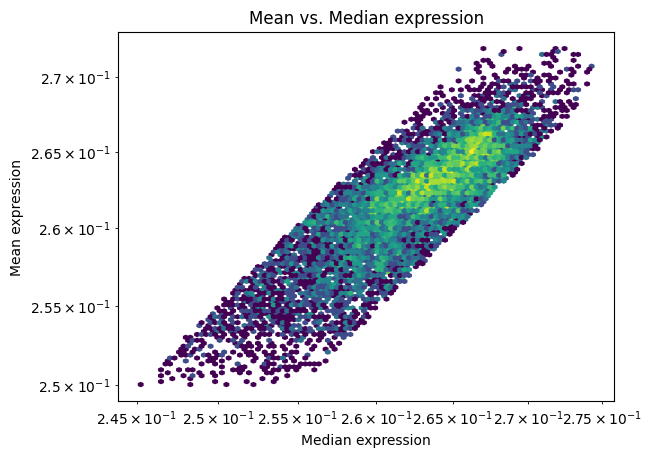

In [ ]:
# Plot of filtered samples gene mean versus median
plt.hexbin(
  x = final_stats['50%'],
  y = final_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

<Axes: ylabel='Count'>

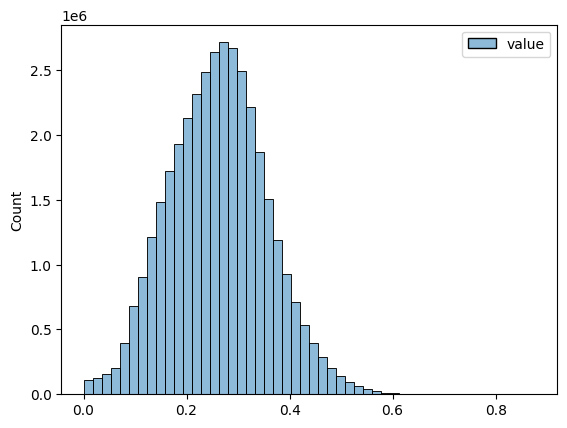

In [ ]:
# Histogram of final filtered data - pretty normal!
sns.histplot(pd.melt(filtered_df.T), bins = 50)

### Final Filtered Data

In [ ]:
# Get size of filtered genes and samples
filtered_df.shape

(3608, 10154)

## 4. Data post-processing and saving

We pull the raw counts for these filtered data and then normalize again through:
- Ratio of Medians
- Log-transform
- 0-1 scaling

Then, we save the data to a CSV.

In [ ]:
raw_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/Copy of num_reads_ecoli_pan_genome_part2_comp_ref_k15v3.csv',
  index_col = 0
)
raw_df.shape

(59521, 20241)

In [ ]:
raw_df.index = raw_df['X']
raw_filt = raw_df.loc[filtered_df.index, filtered_df.columns]
raw_filt.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,89.000,210.000,184.000,97.000,138.000,147.000,372.990,115.000,29.022,57.192,...,1293.000,2456.0,1020.0,2966.00,2871.0,832.0,1343.000,1036.00,948.000,1176.000
11997cc26382b2c286cd502685a104a5_45,190.000,247.000,353.000,111.000,263.000,108.000,326.000,104.000,17.979,23.869,...,1592.000,2505.0,1812.0,506.25,647.0,501.0,761.877,563.00,611.659,599.889
11997cc26382b2c286cd502685a104a5_110,512.188,774.683,494.736,375.694,411.855,148.855,1310.018,278.331,26.225,25.298,...,4473.000,5772.0,3436.0,2976.00,4803.0,2792.0,2721.000,2274.00,2376.000,2393.000
11997cc26382b2c286cd502685a104a5_72,364.959,1070.884,348.464,655.238,418.039,217.520,1457.939,169.932,234.191,251.888,...,73509.995,105679.0,54749.0,1928.00,1996.0,8069.0,10965.000,8550.86,8671.000,105943.000
11997cc26382b2c286cd502685a104a5_273,100.000,168.000,70.185,0.000,0.000,28.000,106.000,72.000,10.000,7.000,...,190.000,262.0,157.0,183.00,253.0,120.0,116.000,100.00,73.000,83.000


In [ ]:
# Ratio of Medians Scaling
norm_counts, size_factors = deseq2_norm(raw_filt.T)
norm_counts = norm_counts.T
norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,168.735077,224.454335,200.758238,168.972182,140.082481,232.088992,199.530930,279.017095,496.329284,784.934406,...,304.785171,420.689268,281.065900,1100.960673,848.571388,299.517514,363.337324,349.470625,332.820794,435.755021
11997cc26382b2c286cd502685a104a5_45,360.220952,264.001051,385.150315,193.359919,266.968787,170.514361,174.393638,252.328503,307.473785,327.591260,...,375.265269,429.082498,499.305305,187.916838,191.231518,180.358503,206.119397,189.915021,214.739276,222.282861
11997cc26382b2c286cd502685a104a5_110,971.057099,828.004559,539.795259,654.451905,418.070075,235.017734,700.793881,675.296584,448.495468,347.203641,...,1054.372831,988.688295,946.806307,1104.672611,1419.605844,1005.111656,736.143604,767.081274,834.158445,886.702182
11997cc26382b2c286cd502685a104a5_72,691.925675,1144.593123,380.201188,1141.412313,424.347395,343.428554,779.924192,412.295070,4005.094458,3457.049198,...,17327.731176,18101.800135,15086.349971,715.661557,589.950711,2904.815887,2966.488281,2884.434734,3044.186818,39256.117551
11997cc26382b2c286cd502685a104a5_273,189.589975,179.563468,76.577266,0.000000,0.000000,44.207427,56.704680,174.688964,171.018291,96.071843,...,44.786684,44.878090,43.262104,67.928457,74.778322,43.199641,31.382822,33.732686,25.628605,30.754819


In [ ]:
# Log2 scaling
log_norm_counts = np.log2(norm_counts + 1)
log_norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,7.407141,7.816691,7.656484,7.409155,7.140395,7.864737,7.647681,8.129371,8.958058,9.618265,...,8.256375,8.720036,8.139888,10.105857,9.730591,8.231305,8.509131,8.453150,8.382930,8.770680
11997cc26382b2c286cd502685a104a5_45,8.496738,8.049854,8.593019,7.602587,8.065921,7.422186,7.454453,7.984866,8.269004,8.360150,...,8.555606,8.748470,8.966665,7.561607,7.586701,7.502701,7.694319,7.576787,7.753145,7.802729
11997cc26382b2c286cd502685a104a5_110,9.924897,9.695236,9.078939,9.356346,8.711048,7.882751,9.454904,9.401512,8.812163,8.443787,...,10.043537,9.950830,9.888448,10.110709,10.472291,9.974575,9.525802,9.585115,9.705906,9.793932
11997cc26382b2c286cd502685a104a5_72,9.436557,10.161879,8.574409,10.157868,8.732498,8.428061,9.609039,8.691028,11.967981,11.755743,...,14.080878,14.143925,13.881052,9.485148,9.206894,11.504728,11.535027,11.494573,11.572315,15.260667
11997cc26382b2c286cd502685a104a5_273,7.574328,7.496362,6.277562,0.000000,0.000000,5.498488,5.850616,7.456880,7.426418,6.600981,...,5.516856,5.519733,5.468000,6.107028,6.243713,5.465963,5.017157,5.118222,4.734905,4.988904


In [ ]:
# 0-1 scaling
log_01_norm_counts = (log_norm_counts - log_norm_counts.min()) / (log_norm_counts.max() - log_norm_counts.min())
log_01_norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,0.462185,0.494386,0.487966,0.452542,0.445669,0.461694,0.473013,0.487469,0.519818,0.539276,...,0.498947,0.528333,0.489850,0.599973,0.579576,0.500972,0.517158,0.515956,0.511575,0.523563
11997cc26382b2c286cd502685a104a5_45,0.530173,0.509133,0.547654,0.464356,0.503436,0.435714,0.461062,0.478804,0.479833,0.468736,...,0.517031,0.530055,0.539605,0.448924,0.451881,0.456627,0.467637,0.462465,0.473142,0.465782
11997cc26382b2c286cd502685a104a5_110,0.619286,0.613199,0.578622,0.571474,0.543702,0.462752,0.584791,0.563752,0.511352,0.473425,...,0.606949,0.602904,0.595077,0.600261,0.623754,0.607070,0.578949,0.585047,0.592310,0.584646
11997cc26382b2c286cd502685a104a5_72,0.588815,0.642713,0.546467,0.620430,0.545041,0.494764,0.594324,0.521149,0.694477,0.659120,...,0.850933,0.856957,0.835347,0.563122,0.548384,0.700198,0.701063,0.701595,0.706209,0.910981
11997cc26382b2c286cd502685a104a5_273,0.472617,0.474126,0.400084,0.000000,0.000000,0.322785,0.361864,0.447144,0.430940,0.370103,...,0.333393,0.334432,0.329059,0.362567,0.371890,0.332668,0.304927,0.312401,0.288951,0.297811


In [ ]:
# Save to a CSV file
log_01_norm_counts.to_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv',
  index = True
)

In [ ]:
# Verify that I can load the CSV back in here
final_filt = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv',
  index_col = 0
)
final_filt.shape

(3608, 10154)